# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [2]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [3]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()


Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

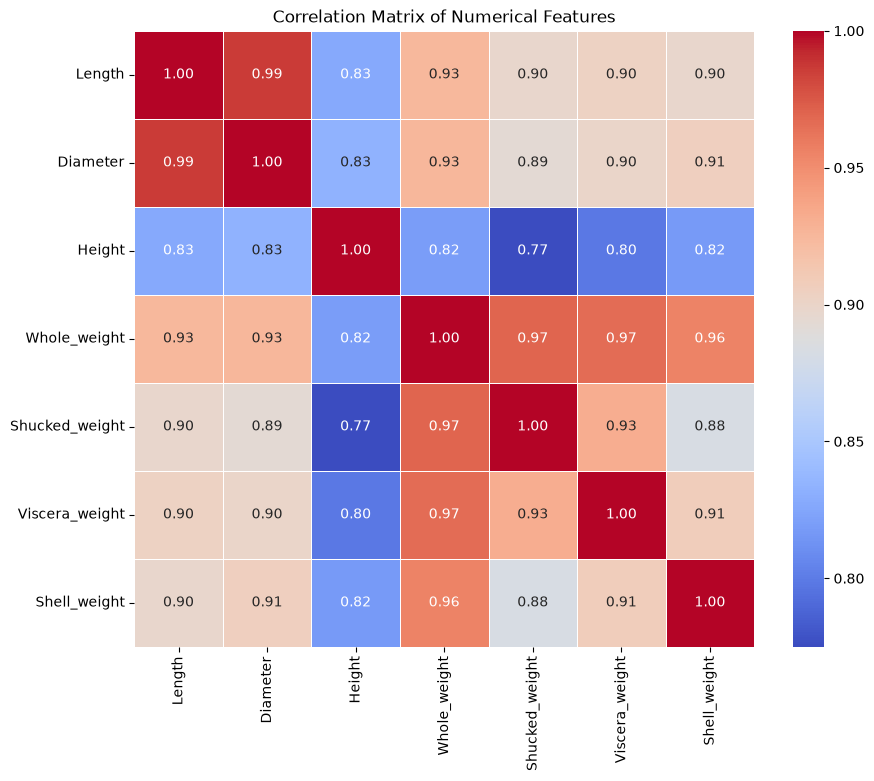

In [4]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
corr_matrix

# Optional heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [5]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df.head()


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


In [6]:
# TODO: Separate your features (X) and target (y)
X = df.drop('Rings', axis=1)
y = df['Rings']


In [7]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)


In [8]:
# TODO: Initialize the StandardScaler
scaler = StandardScaler()

# TODO: Fit the scaler on the training data AND transform X_train. 
X_train_scaled = scaler.fit_transform(X_train)

# TODO: Transform the test data (Do NOT fit the scaler on the test data!)
X_test_scaled = scaler.transform(X_test)


## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE
    """
    print(f"--- {model_name} Performance ---")
    
    # Generate predictions for both X_train and X_test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate R2 for train and test
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Calculate RMSE for train and test
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Print the results clearly
    print(f"Train R2: {train_r2:.4f}, Train RMSE: {train_rmse:.4f}")
    print(f"Test R2: {test_r2:.4f}, Test RMSE: {test_rmse:.4f}")
    print()

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [10]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# TODO: Use your custom evaluate_model() function to check its performance
evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Linear Regression")


--- Linear Regression Performance ---
Train R2: 0.5349, Train RMSE: 2.2113
Test R2: 0.5497, Test RMSE: 2.1116



## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [11]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Ridge Regression")

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)
print(f"Best alpha for Ridge: {ridge_model.alpha_}")


--- Ridge Regression Performance ---
Train R2: 0.5349, Train RMSE: 2.2114
Test R2: 0.5497, Test RMSE: 2.1118

Best alpha for Ridge: 1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [12]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10 
# and fit it to the training data
lasso_model = LassoCV(cv=5, random_state=10)
lasso_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Lasso Regression")

# TODO: Print the best alpha found by LassoCV
print(f"Best alpha for Lasso: {lasso_model.alpha_}")


--- Lasso Regression Performance ---
Train R2: 0.5347, Train RMSE: 2.2118
Test R2: 0.5493, Test RMSE: 2.1126

Best alpha for Lasso: 0.003102557702171799


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [13]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data
elasticnet_model = ElasticNetCV(cv=5, random_state=10)
elasticnet_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(elasticnet_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="ElasticNet")

# TODO: Print the best alpha found by ElasticNetCV
print(f"Best alpha for ElasticNet: {elasticnet_model.alpha_}")


--- ElasticNet Performance ---
Train R2: 0.5335, Train RMSE: 2.2148
Test R2: 0.5480, Test RMSE: 2.1156

Best alpha for ElasticNet: 0.004082551587352136


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [14]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elasticnet_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__ Lasso set the coefficient for **Length** to 0. This means Length was the least important feature and Lasso's L1 regularization completely eliminated it from the model.


__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__ ElasticNet combines L1 and L2 penalties. Unlike Lasso, it did not zero out any coefficients completely (Length remains at 0.029). Its coefficient magnitudes are generally lower compared to those of Ridge and Lasso — for example, Whole_weight is 3.161 (vs 4.202 for Ridge and 3.955 for Lasso). This shows ElasticNet's hybrid approach: it shrinks coefficients like Ridge but doesn't force them to zero as aggressively as Lasso.


## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**Your Answer:**

Our model can predict an abalone's age with reasonable accuracy — it captures about 55-60% of the factors that determine age, and on average it's off by about 2 rings. This is not precise enough to fully replace the manual counting method for regulatory compliance, since a 2-ring error could mean the difference between a legal and illegal harvest. However, it is a valuable screening tool: it can quickly flag approximate age ranges, allowing the lab to prioritize which samples need the full microscopic inspection. This can save significant time and reduce costs for both wild fisheries and aquaculture operations.


# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [15]:
# 1. Feature Engineering: Create a 'Length_to_Height' ratio feature
# Ratio of Length to Height - biologically, a taller (higher height) abalone for a given length may be older
X['Length_Height_Ratio'] = X['Length'] / X['Height'].replace(0, np.nan)

# Re-split, re-scale, and re-evaluate
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=10)

# Drop any remaining NaN rows
X_train2 = X_train2.dropna()
X_test2 = X_test2.dropna()
y_train2 = y_train2[X_train2.index]
y_test2 = y_test2[X_test2.index]

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# RidgeCV on new features
ridge2 = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge2.fit(X_train2_scaled, y_train2)
evaluate_model(ridge2, X_train2_scaled, X_test2_scaled, y_train2, y_test2, model_name="Ridge with Engineered Feature")

# 2. Feature Selection: Use LassoCV to identify features to keep
lasso_selector = LassoCV(cv=5, random_state=10)
lasso_selector.fit(X_train2_scaled, y_train2)
selected_features = X.columns[lasso_selector.coef_ != 0]
print(f"Features retained by Lasso: {list(selected_features)}")
print(f"Features dropped by Lasso: {list(X.columns[lasso_selector.coef_ == 0])}")

--- Ridge with Engineered Feature Performance ---
Train R2: 0.5399, Train RMSE: 2.1994
Test R2: 0.4772, Test RMSE: 2.2753

Features retained by Lasso: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_I', 'Sex_M', 'Length_Height_Ratio']
Features dropped by Lasso: []
